<a href="https://colab.research.google.com/github/FatherNurt/FUNt-Cosmologiical-Model-of-All-Things/blob/main/FPDP_Engine_v1_1_Fixed_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FPDP Engine v1.1
## Canonical Naming / Dependency Graph Edition

**Flow • Potential Difference • Persistence**

Historical / descriptive analysis only. **No prediction performed.**


## Canonical dependency graph

```text
FUNt
   ↓ defines
FPDP Mathematics
   ↓ implemented by
FPDP Engine
   ↓ executes
FPDP History Analysis
   ↓ generates
History Plot Against h³π and Ψ
   ↓ supported by
Domain Adapters
   ↓ produces
Standard Outputs
```


## Machine-readable architecture

```yaml
Theory:
  name: FUNt
  relationship: defines

Mathematics:
  name: FPDP Mathematics
  definition: Flow • Potential Difference • Persistence
  relationship: implemented by

Engine:
  name: FPDP Engine
  relationship: executes

Primary Analysis:
  name: FPDP History Analysis
  visualization: History Plot Against h³π and Ψ

Adapters:
  required_columns:
    - time
    - flow
    - potential_difference

Outputs:
  - SITREP
  - History Plot
  - Audit
```


## Core definitions

**Flow** — observed movement, activity, transfer, or change.

**Potential Difference** — gradient, stress, imbalance, contrast, or driver.

**Persistence** — rolling survival of FPDP pressure relative to Ψ.

```text
FPDP pressure = |Flow| × |Potential Difference|
h³π ratio = FPDP pressure / h³π
Persistence = rolling mean(FPDP pressure)
Ψ ratio = Persistence / Ψ
```


In [1]:
from __future__ import annotations

from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, Any
import datetime as dt
import hashlib
import json
import math

import pandas as pd
import matplotlib.pyplot as plt


H3PI = 3.0 * math.pi
PSI_REFERENCE = 1.4656


@dataclass(frozen=True)
class FPDPConfig:
    theory: str = "FUNt"
    mathematics: str = "FPDP Mathematics"
    mathematics_definition: str = "Flow • Potential Difference • Persistence"
    engine: str = "FPDP Engine"
    engine_version: str = "v1.1"
    primary_analysis: str = "FPDP History Analysis"
    visualization: str = "History Plot Against h³π and Ψ"
    h3pi: float = H3PI
    psi_reference: float = PSI_REFERENCE
    persistence_window: int = 3
    time_column: str = "time"
    flow_column: str = "flow"
    potential_difference_column: str = "potential_difference"
    classification: str = "Historical / descriptive analysis only. No prediction performed."


def dependency_graph() -> Dict[str, Any]:
    return {
        "Theory": {"name": "FUNt", "relationship": "defines", "next": "FPDP Mathematics"},
        "Mathematics": {
            "name": "FPDP Mathematics",
            "definition": "Flow • Potential Difference • Persistence",
            "relationship": "implemented by",
            "next": "FPDP Engine",
        },
        "Engine": {"name": "FPDP Engine", "relationship": "executes", "next": "FPDP History Analysis"},
        "Primary Analysis": {
            "name": "FPDP History Analysis",
            "relationship": "generates",
            "next": "History Plot Against h³π and Ψ",
        },
        "Adapters": {
            "relationship": "translate domain observations into canonical FPDP columns",
            "required_columns": ["time", "flow", "potential_difference"],
            "examples": ["Earthquake", "Solar Weather", "Biology", "Climate"],
        },
        "Outputs": ["SITREP", "History Plot", "Audit"],
    }


def sha256_text(text: str) -> str:
    return hashlib.sha256(text.encode("utf-8")).hexdigest()


def canonicalize_observations(df: pd.DataFrame, config: FPDPConfig = FPDPConfig()) -> pd.DataFrame:
    required = [config.time_column, config.flow_column, config.potential_difference_column]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required canonical FPDP columns: {missing}")

    history = df.copy()
    history[config.time_column] = pd.to_datetime(history[config.time_column], utc=True, errors="coerce")
    history = history.dropna(subset=[config.time_column]).sort_values(config.time_column).reset_index(drop=True)

    history["flow"] = pd.to_numeric(history[config.flow_column], errors="coerce")
    history["potential_difference"] = pd.to_numeric(history[config.potential_difference_column], errors="coerce")
    history = history.dropna(subset=["flow", "potential_difference"]).reset_index(drop=True)

    history["fpdp_pressure"] = history["flow"].abs() * history["potential_difference"].abs()
    history["h3pi_ratio"] = history["fpdp_pressure"] / config.h3pi
    history["persistence"] = history["fpdp_pressure"].rolling(
        window=config.persistence_window, min_periods=1
    ).mean()
    history["psi_ratio"] = history["persistence"] / config.psi_reference

    history["above_h3pi"] = history["fpdp_pressure"] >= config.h3pi
    history["above_psi"] = history["persistence"] >= config.psi_reference
    history["fpdp_transition_candidate"] = history["above_h3pi"] & history["above_psi"]

    return history


def run_fpdp_history_analysis(
    observations: pd.DataFrame,
    output_dir: str | Path = "fpdp_history_analysis_output",
    config: FPDPConfig = FPDPConfig(),
) -> Dict[str, Any]:
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    history = canonicalize_observations(observations, config)

    history_path = output_dir / "fpdp_history.csv"
    history.to_csv(history_path, index=False)

    latest = history.iloc[-1] if len(history) else None
    sitrep = {
        "theory": config.theory,
        "mathematics": config.mathematics,
        "mathematics_definition": config.mathematics_definition,
        "engine": config.engine,
        "engine_version": config.engine_version,
        "primary_analysis": config.primary_analysis,
        "visualization": config.visualization,
        "classification": config.classification,
        "generated_utc": dt.datetime.now(dt.timezone.utc).isoformat(),
        "records": int(len(history)),
        "transition_candidates": int(history["fpdp_transition_candidate"].sum()) if len(history) else 0,
        "latest": None if latest is None else {
            "time": str(latest["time"]),
            "fpdp_pressure": float(latest["fpdp_pressure"]),
            "h3pi_ratio": float(latest["h3pi_ratio"]),
            "persistence": float(latest["persistence"]),
            "psi_ratio": float(latest["psi_ratio"]),
            "transition_candidate": bool(latest["fpdp_transition_candidate"]),
        },
    }

    sitrep_path = output_dir / "sitrep.json"
    sitrep_path.write_text(json.dumps(sitrep, indent=2), encoding="utf-8")

    graph = dependency_graph()
    graph_path = output_dir / "dependency_graph.json"
    graph_path.write_text(json.dumps(graph, indent=2), encoding="utf-8")

    plot_path = output_dir / "history_plot_against_h3pi_and_psi.png"
    plt.figure(figsize=(12, 6))
    plt.plot(history["time"], history["fpdp_pressure"], label="FPDP pressure")
    plt.plot(history["time"], history["persistence"], label="Persistence")
    plt.axhline(config.h3pi, linestyle="--", label="h³π")
    plt.axhline(config.psi_reference, linestyle=":", label="Ψ")
    plt.title("FPDP History Analysis: History Plot Against h³π and Ψ")
    plt.xlabel("Time")
    plt.ylabel("Canonical FPDP units")
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_path, dpi=180)
    plt.close()

    config_json = json.dumps(asdict(config), sort_keys=True, indent=2)
    history_csv = history.to_csv(index=False)
    audit = {
        "audit_type": "FPDP Engine Audit",
        "created_utc": dt.datetime.now(dt.timezone.utc).isoformat(),
        "dependency_graph": graph,
        "config": asdict(config),
        "config_sha256": sha256_text(config_json),
        "history_sha256": sha256_text(history_csv),
        "scientific_boundary": [
            "Historical/descriptive analysis only.",
            "No prediction performed.",
            "A transition candidate is a descriptive gate result, not proof of causation.",
            "Adapters translate domains; the engine only processes canonical FPDP columns.",
        ],
    }

    audit_path = output_dir / "audit.json"
    audit_path.write_text(json.dumps(audit, indent=2), encoding="utf-8")

    return {
        "sitrep": sitrep,
        "history_csv": str(history_path),
        "sitrep_json": str(sitrep_path),
        "audit_json": str(audit_path),
        "dependency_graph_json": str(graph_path),
        "history_plot_png": str(plot_path),
    }


def demo_observations() -> pd.DataFrame:
    return pd.DataFrame({
        "time": pd.date_range("2026-06-26T00:00:00Z", periods=12, freq="h"),
        "flow": [0.4, 0.7, 0.9, 1.2, 2.4, 3.0, 3.6, 2.2, 1.4, 1.0, 0.8, 0.6],
        "potential_difference": [0.5, 0.6, 1.0, 1.2, 2.4, 3.5, 3.2, 2.1, 1.4, 1.0, 0.7, 0.5],
        "domain": ["demo"] * 12,
        "source": ["synthetic demonstration"] * 12,
    })


## Demonstration run

This synthetic demonstration checks the engine path and output structure. It is not a prediction and is not domain evidence.


In [2]:
demo = demo_observations()
demo


,time,flow,potential_difference,domain,source
0,2026-06-26 00:00:00+00:00,0.4,0.5,demo,synthetic demonstration
1,2026-06-26 01:00:00+00:00,0.7,0.6,demo,synthetic demonstration
2,2026-06-26 02:00:00+00:00,0.9,1.0,demo,synthetic demonstration
3,2026-06-26 03:00:00+00:00,1.2,1.2,demo,synthetic demonstration
4,2026-06-26 04:00:00+00:00,2.4,2.4,demo,synthetic demonstration
5,2026-06-26 05:00:00+00:00,3.0,3.5,demo,synthetic demonstration
6,2026-06-26 06:00:00+00:00,3.6,3.2,demo,synthetic demonstration
7,2026-06-26 07:00:00+00:00,2.2,2.1,demo,synthetic demonstration
8,2026-06-26 08:00:00+00:00,1.4,1.4,demo,synthetic demonstration
9,2026-06-26 09:00:00+00:00,1.0,1.0,demo,synthetic demonstration


In [3]:
result = run_fpdp_history_analysis(demo, output_dir='fpdp_engine_v1_1_demo_output')
result['sitrep']


{'theory': 'FUNt',
 'mathematics': 'FPDP Mathematics',
 'mathematics_definition': 'Flow • Potential Difference • Persistence',
 'engine': 'FPDP Engine',
 'engine_version': 'v1.1',
 'primary_analysis': 'FPDP History Analysis',
 'visualization': 'History Plot Against h³π and Ψ',
 'classification': 'Historical / descriptive analysis only. No prediction performed.',
 'generated_utc': '2026-06-27T18:08:09.158890+00:00',
 'records': 12,
 'transition_candidates': 2,
 'latest': {'time': '2026-06-26 11:00:00+00:00',
  'fpdp_pressure': 0.3,
  'h3pi_ratio': 0.03183098861837907,
  'persistence': 0.62,
  'psi_ratio': 0.4230349344978166,
  'transition_candidate': False}}

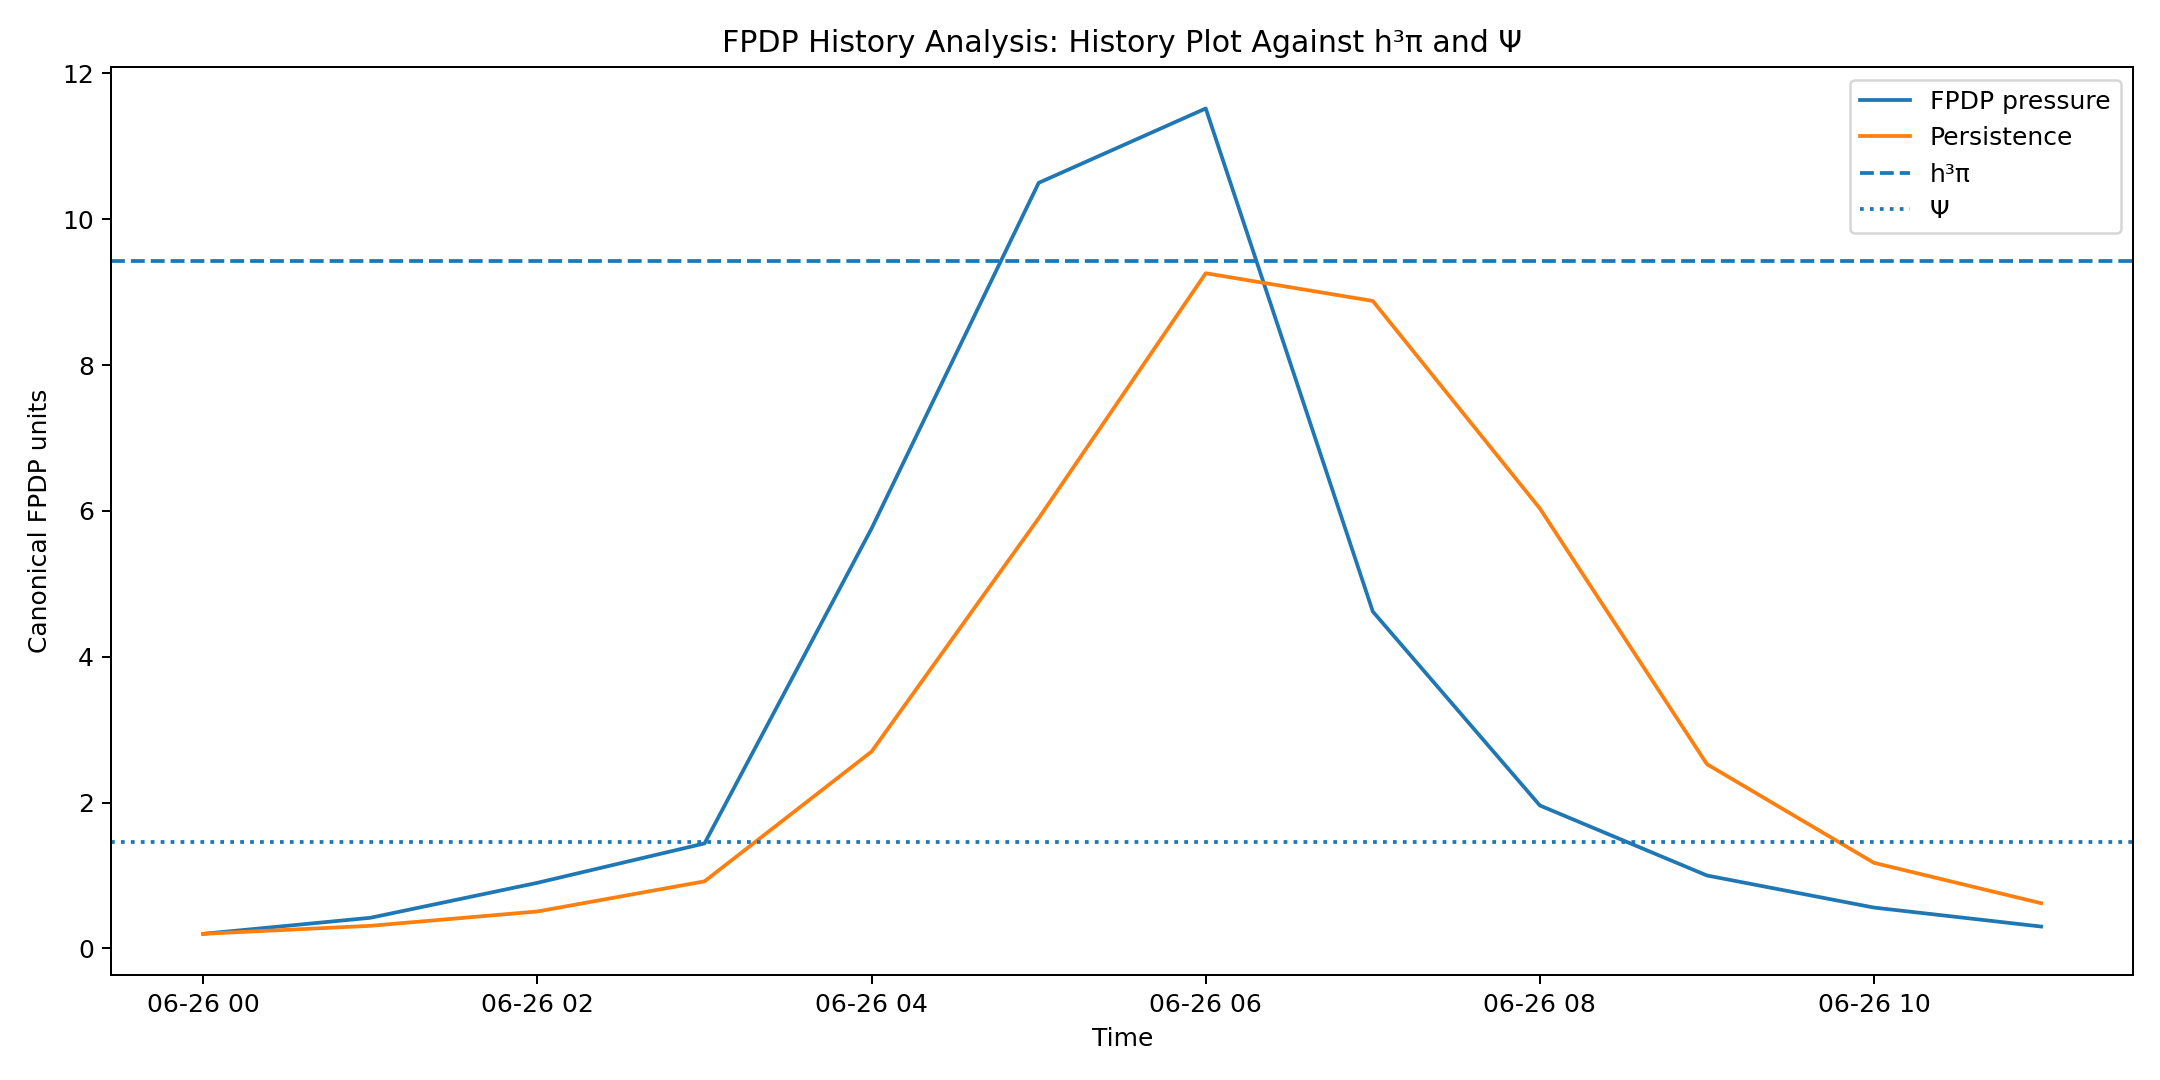

In [4]:
from IPython.display import Image, display
display(Image(result['history_plot_png']))


## Adapter notes

Adapters are domain translators. They do not change the engine mathematics.

- Earthquake Adapter: seismic sequence → flow / potential_difference
- Solar Weather Adapter: field and particle disturbance → flow / potential_difference
- Biology Adapter: repair, transport, or signal dynamics → flow / potential_difference
- Climate Adapter: gradient and transport records → flow / potential_difference

The engine only sees canonical FPDP columns.


## Summary Statistics for FPDP History


In [5]:
fpdp_history_df = pd.read_csv(result['history_csv'])
display(fpdp_history_df.describe())


,flow,potential_difference,fpdp_pressure,h3pi_ratio,persistence,psi_ratio
count,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000
mean,1.516667,1.508333,3.265000,0.346427,3.252500,2.219228
std,1.036457,1.049206,4.021588,0.426704,3.378305,2.305066
min,0.400000,0.500000,0.200000,0.021221,0.200000,0.136463
25%,0.775000,0.675000,0.525000,0.055704,0.591667,0.403703
50%,1.100000,1.100000,1.220000,0.129446,1.850000,1.262282
75%,2.250000,2.175000,4.905000,0.520437,5.933333,4.048399
max,3.600000,3.500000,11.520000,1.222310,9.260000,6.318231
